In [3]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '..')))
from tools import *
from macro import macros

L1 = read_parameters("/data1/DATA_Duplat/Brut/PDF/PD1n1")[0]
L2 = read_parameters("/data1/DATA_Duplat/Brut/PDF/PD1n1")[1]


# How does the different quantities evolves with $\tau$ 

## Load of $\tau$

In [4]:
def process_size(folder, Lengthtab, nmin, nmax):
    data = np.loadtxt(f"{folder}/stat_histosize.txt", comments = "#")
    
    if folder == "/data1/DATA_Duplat/Brut/PDF/PD1n1":
        fnb2 = np.arange(1,10)
        folderpath2 = [f'/data1/DATA_Duplat/Brut/PDF/PD3n{nb}' for nb in fnb2]
        
        for folder in folderpath2:
            data += np.loadtxt(f"{folder}/stat_histosize.txt") 
    
    last_non_zero = np.nonzero(data)[0]
    
    nbins = freedman_diaconis_log_bins(data)
    
    mean = np.sum(data * np.arange(len(data)))/np.sum(data)
    
    ndatafit, ndistloglog, nstat = mainfct(data, Lengthtab, nbins, nmin, nmax)
    Tndist = 10 ** ndistloglog
    Tndatafit = 10 ** ndatafit
    Tnstat = nstat[0]
    
    return Tndist, Tndatafit, Tnstat, last_non_zero[-1], mean, nbins


    

In [5]:
lengthtab = L1 * L2
nbins = 100
Tnmin = np.array([5,8, 8,8,7,7,7, 8,8,8,8, 8, 8, 8,8])
Tnmax = np.array([80,45,50,50,50,50,50, 80,80,80,80,80,80,80])
fnb = np.arange(1,15)
folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD1n{nb}' for nb in fnb]
Tvar = [read_parameters(folder)[2] for folder in folderpath]

results = Parallel(n_jobs=-1)(delayed(process_size)(folder, lengthtab, nmin, nmax)
                                  for (folder, nmin, nmax) in zip(folderpath, Tnmin, Tnmax))




In [6]:
Tndist_s = np.zeros((len(folderpath),nbins, 2))
Tnstat_s = np.zeros(len(folderpath))
Tnonzero_s = np.zeros(len(folderpath))
Tmean_s = np.zeros(len(folderpath))
Tndatafit_s = np.zeros((len(folderpath),2,2))
Tnbins_s = np.zeros(len(folderpath))

NCURVES = len(folderpath) +1
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]

stop = [2e-6,4e-5,3e-5,3e-5,5e-5,5e-5,3e-5,1e-7, 1e-8, 1e-9, 1e-10, 1e-11, 1e-11, 1e-12]
start_x = [4,5,2,2,2,2,1,2,4,4,4,4,4,4,4]
Ttau_s = np.zeros(len(folderpath))
Tperr_s = np.zeros(len(folderpath))

for j, (Tndist_j, Tndatafit_j, Tnstat_j, Tnzero_j, mean_j, nbins_j) in enumerate(results):
    # Tndist_s[j] = Tndist_j
    Tndatafit_s[j] = Tndatafit_j
    Tnstat_s[j] = Tnstat_j    
    Tnonzero_s[j] = Tnzero_j
    Tmean_s[j] = mean_j
    Tnbins_s[j] = nbins_j
    
    
    mask = Tndist_j[:,1] != 1
    
    xs_final = 0
    result_final = 0
    perr_final = 1e10
    x_final = 0
    for x in range(1,11):
        result, xs, _ , perr = fit_powerlaw(Tndist_j[:,0][mask], Tndist_j[:,1][mask], n_cutoff = stop[j], start_x = x, plot=True, f_scale=1.0,
                                    function_to_fit='power')
        if (perr[1] < perr_final):
            perr_final = perr[1]
            xs_final = xs
            result_final = result
            x_final = x

    
    Ttau_s[j] = np.round(result_final.x[1], 2)
    Tperr_s[j] =  np.round(perr_final, 2)
    



## Mean size

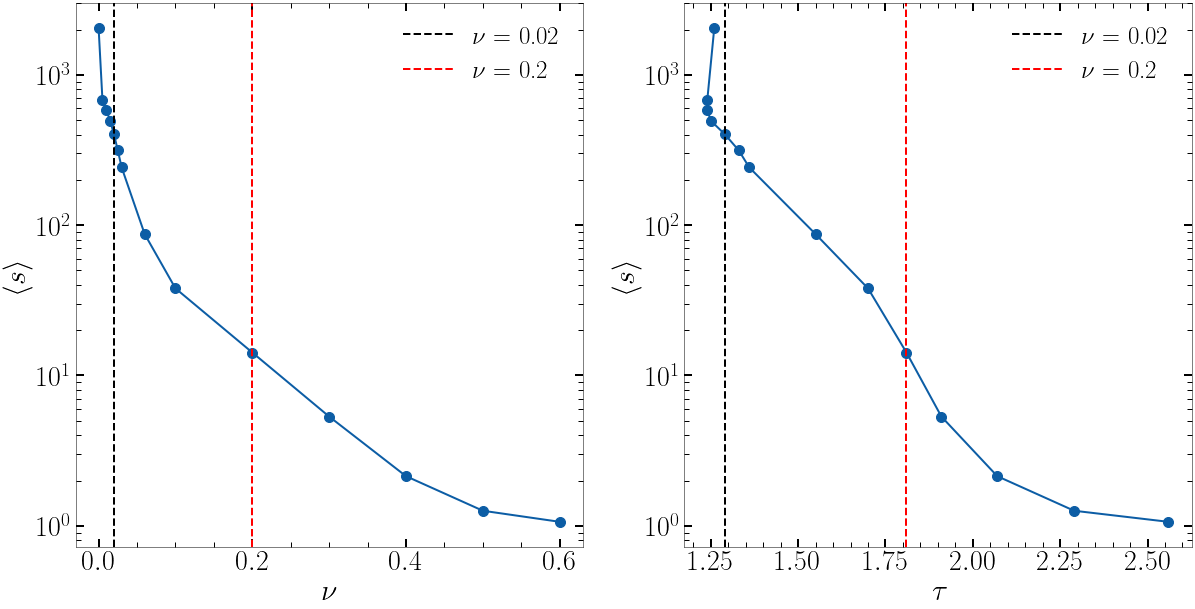

In [118]:
plt.figure(figsize = (20,10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

ax1.plot(Tvar, Tmean_s, lw = 2, marker = 'o', markersize= 10)
ax2.plot(-Ttau_s, Tmean_s, lw = 2, marker = 'o', markersize = 10)

ax1.axvline(Tvar[4], ls = '--', lw =2, c = 'k', label = '{} = {}'.format( macros['diss'], Tvar[4]))
ax1.axvline(Tvar[9], ls = '--', lw =2, c = 'r', label = '{} = {}'.format(macros['diss'], Tvar[9]))
ax1.set_xlabel('{}'.format(macros['diss']), fontsize = 30)
ax1.set_ylabel('{}'.format(macros['mean_s']), fontsize = 30)
ax1.set_yscale('log')
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
ax1.legend(fontsize = 25)

ax2.axvline(-Ttau_s[4], ls = '--', lw =2, c = 'k', label = '{} = {}'.format( macros['diss'], Tvar[4]))
ax2.axvline(-Ttau_s[9], ls = '--', lw =2, c = 'r', label = '{} = {}'.format(macros['diss'], Tvar[9]))
# ax2.axvline(-Ttau_s[12], ls = '--', lw =2, c = 'g', label = '{} = {}'.format(macros['diss'], Tvar[12]))
ax2.set_xlabel('{}'.format(macros['exp_s']), fontsize = 30)
ax2.set_ylabel('{}'.format(macros['mean_s']), fontsize = 30)
ax2.set_yscale('log')
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
ax2.legend(fontsize = 25)
plt.show()


## Smax

## Topplings

In [33]:
def process_top(folder, Lengthtab, nbins, nmin, nmax):
    data = np.loadtxt(f"{folder}/stat_histotop.txt", comments = "#")
    
    last_non_zero = np.nonzero(data)[0]
    
    mean = np.sum(data * np.arange(len(data)))/np.sum(data)
    
    ndatafit, ndistloglog, nstat = mainfct(data, Lengthtab, nbins, nmin, nmax)
    Tndist = 10 ** ndistloglog
    Tndatafit = 10 ** ndatafit
    Tnstat = nstat[0]
    
    return Tndist, Tndatafit, Tnstat, last_non_zero[-1], mean

def chunked_file_reader(filepath, chunksize=1e7, usecols=None):
        for chunk in pd.read_csv(filepath, compression='gzip', delim_whitespace=True, header=None, chunksize=chunksize, usecols=usecols, comment = "#"):
            yield chunk

In [34]:

Tnmin = np.array([5,8, 8,8,7,7,7, 8,8,8,8, 8, 8, 8, 8])
Tnmax = np.array([75,40,50,50,50,50,50, 80,80,80,80,80,80, 80])
nbins = 100
lengthtab = L1 * L2 * 1000

fnb = np.arange(1,15)
folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD1n{nb}' for nb in fnb]
Tvar = [read_parameters(folder)[2] for folder in folderpath]

results = Parallel(n_jobs=-1)(delayed(process_top)(folder, lengthtab, nbins, nmin, nmax)
                                  for (folder, nmin, nmax) in zip(folderpath, Tnmin, Tnmax))

In [35]:
Tndist_t = np.zeros((len(folderpath),nbins, 2))
Tnstat_t = np.zeros(len(folderpath))
Tnonzero_t = np.zeros(len(folderpath))
Tmean_t = np.zeros(len(folderpath))
Tndatafit_t = np.zeros((len(folderpath),2,2))

NCURVES = len(folderpath)
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]

stop = [2e-8,4e-5,3e-5,3e-5,5e-5,5e-5,3e-5,1e-7, 1e-8, 1e-9, 1e-10, 1e-11, 1e-11, 1e-12]
start_x = [4,5,2,2,2,2,1,2,4,4,4,4,4,4,4]
Ttau_t = np.zeros(len(folderpath))
Tperr_t = np.zeros(len(folderpath))

for j, (Tndist_j, Tndatafit_j, Tnstat_j, Tnzero_j, mean_j) in enumerate(results):
    Tndist_t[j] = Tndist_j
    Tndatafit_t[j] = Tndatafit_j
    Tnstat_t[j] = Tnstat_j    
    Tnonzero_t[j] = Tnzero_j
    Tmean_t[j] = mean_j
    
    mask = Tndist_j[:,1] != 1
    
    xs_final = 0
    result_final = 0
    perr_final = 1e10
    x_final = 0
    for x in range(1,11):
        result, xs, _ , perr = fit_powerlaw(Tndist_j[:,0][mask], Tndist_j[:,1][mask], n_cutoff = stop[j], start_x = x, plot=True, f_scale=1.0,
                                    function_to_fit='power')
        if (perr[1] < perr_final):
            perr_final = perr[1]
            xs_final = xs
            result_final = result
            x_final = x

    
    Ttau_t[j] = np.round(result_final.x[1], 2)
    Tperr_t[j] =  np.round(perr_final, 2)
    


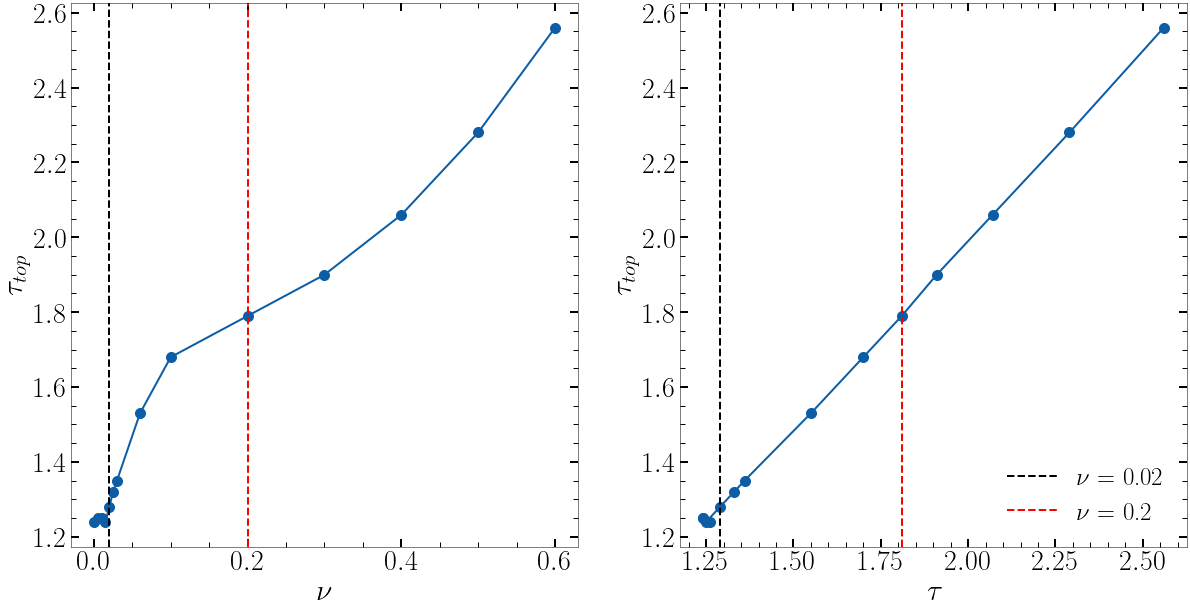

In [121]:
plt.figure(figsize = (20,10))

ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

ax1.plot(Tvar, -Ttau_t, lw = 2, marker = 'o', markersize = 10)
ax2.plot(-Ttau_s, -Ttau_t, lw = 2, marker = 'o', markersize = 10)

ax1.set_xlabel('{}'.format(macros['diss']), fontsize = 30)
ax1.set_ylabel('{}'.format(macros['exp_top']), fontsize = 30)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
ax1.axvline(Tvar[4], ls = '--', lw =2, c = 'k', label = '{} = {}'.format( macros['diss'], Tvar[4]))
ax1.axvline(Tvar[9], ls = '--', lw =2, c = 'r', label = '{} = {}'.format(macros['diss'], Tvar[9]))
# ax1.axvline(Tvar[12], ls = '--', lw =2, c = 'g', label = '{} = {}'.format(macros['diss'], Tvar[12]))

ax2.set_xlabel('{}'.format(macros['exp_s']), fontsize = 30)
ax2.set_ylabel('{}'.format(macros['exp_top']), fontsize = 30)
ax2.axvline(-Ttau_s[4], ls = '--', lw =2, c = 'k', label = '{} = {}'.format( macros['diss'], Tvar[4]))
ax2.axvline(-Ttau_s[9], ls = '--', lw =2, c = 'r', label = '{} = {}'.format(macros['diss'], Tvar[9]))
# ax2.axvline(-Ttau_s[12], ls = '--', lw =2, c = 'g', label = '{} = {}'.format(macros['diss'], Tvar[12]))
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
ax2.legend(fontsize = 25)
plt.show()


## Mean inter time

In [47]:
def process_meantime(folder, nbins):
    histo = np.loadtxt(f"{folder}/stat_histoitime.txt", comments = "#")
    bins = np.logspace(np.log10(10**-12), np.log10(2), nbins)

    bin_centers = (bins[:-1] + bins[1:]) / 2
    mean = np.sum(histo * bin_centers) / np.sum(histo)
    
    return mean

In [123]:
nbins = 1000

fnb = np.arange(1,15)
folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD1n{nb}' for nb in fnb]
Tvar2 = [read_parameters(folder)[2] for folder in folderpath]



results1 = Parallel(n_jobs=-1)(delayed(process_meantime)(folder, nbins + 1)
                                  for folder in folderpath)

In [50]:
def process_meantime_th(folder, minsize, limdata = 1e9):

    histo = np.zeros(nbins)
    bins = np.logspace(np.log10(10**-12), np.log10(10**2), nbins + 1)
    csize = 1e7
    nbdata = 0
    
    lasttime = 0
    last_filtered_time = 0
    norm = 0
    suminter  = 0
    
    for chunk in chunked_file_reader(f'{folder}/Avalanche_outputB.gz', chunksize=csize, usecols = [1,3]):
        
        time = np.array(np.cumsum(chunk.iloc[:, 1])) + lasttime #rebuild the time scale starting from zero using dz
        lasttime = time[-1]  #Save the time for the next chunk
        # filterd_chunk = chunk.iloc[:, 1][chunk.iloc[:, 0] >= minsize]
        
        filtered_time = time[chunk.iloc[:, 0] >= minsize] #Keep only the avalanches with a size above a threshold
        filtered_time = np.insert(filtered_time, 0, last_filtered_time) #add to the array the time of the last avalanches from the previous chunk
        last_filtered_time = filtered_time[-1]  #Keep the time of the last avalanches for the next chunk
        
        if(len(filtered_time) > 0):
            time_inter = np.diff(filtered_time)
            
            suminter += np.sum(time_inter)
            norm += len(time_inter)
            
        nbdata+=len(time)
        
        if nbdata >= limdata: break
        
        
    # histo = histo/nbdata
    mean = suminter/norm
        
    return mean
        

In [125]:
fnb = np.arange(1,14)
folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD1n{nb}' for nb in fnb]
Tvar = [read_parameters(folder)[2] for folder in folderpath]

limdata = 1e8
minsize = 2
results2 = Parallel(n_jobs=-1)(delayed(process_meantime_th)(folder, minsize, limdata)
                                  for folder in folderpath)

In [69]:
limdata = 1e8
minsize = 10
results10 = Parallel(n_jobs=-1)(delayed(process_meantime_th)(folder, minsize, limdata)
                                  for folder in folderpath)

In [70]:
limdata = 1e8
minsize = 100
results100 = Parallel(n_jobs=-1)(delayed(process_meantime_th)(folder, minsize, limdata)
                                  for folder in folderpath)

In [71]:
limdata = 1e8
minsize = 1000
results1000 = Parallel(n_jobs=-1)(delayed(process_meantime_th)(folder, minsize, limdata)
                                  for folder in folderpath)

In [72]:
limdata = 1e8
minsize = 10000
results10000 = Parallel(n_jobs=-1)(delayed(process_meantime_th)(folder, minsize, limdata)
                                  for folder in folderpath)

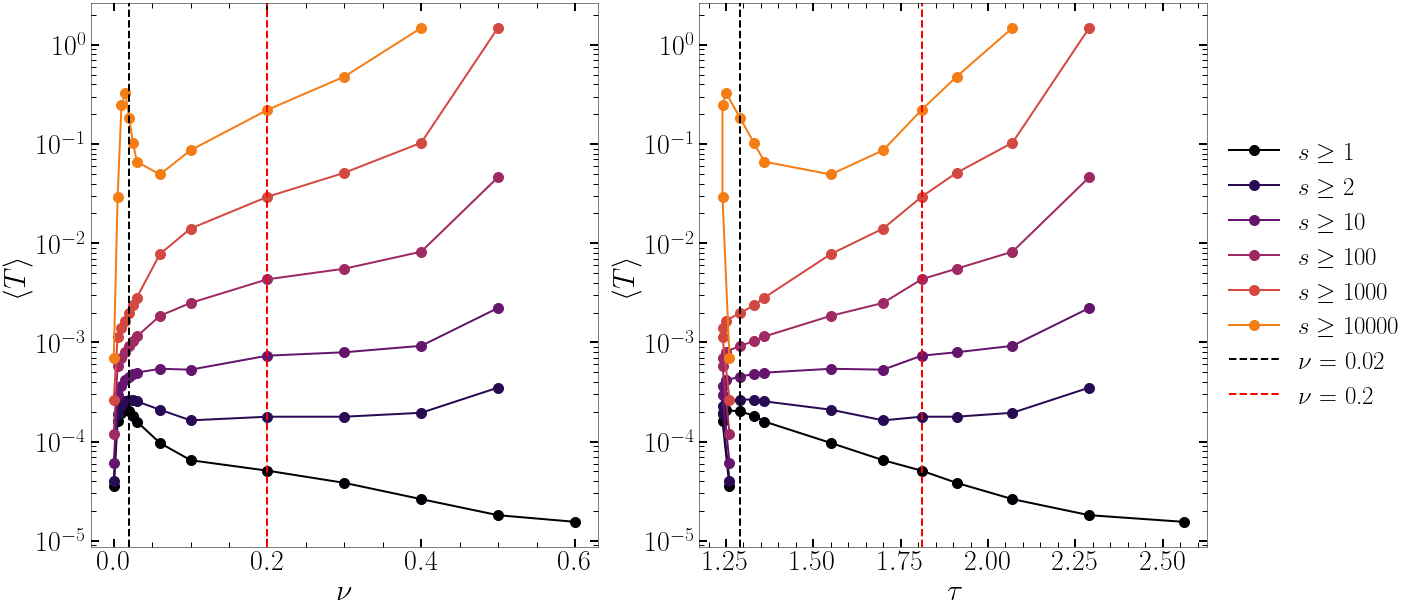

In [126]:


plt.figure(figsize = (20,10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

NCURVES = 7
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]

ax1.plot(Tvar2, results1, lw = 2, marker = 'o', markersize = 10, color = colors[0], label = r"$s \geq  1$" )
ax1.plot(Tvar, results2, lw = 2, marker = 'o', markersize = 10, color = colors[1], label = r"$s \geq  2$" )
ax1.plot(Tvar, results10, lw = 2, marker = 'o', markersize = 10, color = colors[2], label = r"$s \geq  10$" )
ax1.plot(Tvar, results100, lw = 2, marker = 'o', markersize = 10, color = colors[3], label = r"$s \geq  100$" )
ax1.plot(Tvar, results1000, lw = 2, marker = 'o', markersize = 10, color = colors[4], label = r"$s \geq  1000$" )
ax1.plot(Tvar, results10000, lw = 2, marker = 'o', markersize = 10, color = colors[5], label = r"$s \geq  10000$" )
ax1.axvline(Tvar[4], ls = '--', lw =2, c = 'k', label = '{} = {}'.format( macros['diss'], Tvar[4]))
ax1.axvline(Tvar[9], ls = '--', lw =2, c = 'r', label = '{} = {}'.format(macros['diss'], Tvar[9]))
# ax1.axvline(Tvar[12], ls = '--', lw =2, c = 'g', label = '{} = {}'.format(macros['diss'], Tvar[12]))

ax2.plot(-Ttau_s, results1, lw = 2, marker = 'o', markersize = 10, color = colors[0] )
ax2.plot(-Ttau_s[:-1], results2, lw = 2, marker = 'o', markersize = 10, color = colors[1] )
ax2.plot(-Ttau_s[:-1], results10, lw = 2, marker = 'o', markersize = 10, color = colors[2] )
ax2.plot(-Ttau_s[:-1], results100, lw = 2, marker = 'o', markersize = 10, color = colors[3] )
ax2.plot(-Ttau_s[:-1], results1000, lw = 2, marker = 'o', markersize = 10, color = colors[4] )
ax2.plot(-Ttau_s[:-1], results10000, lw = 2, marker = 'o', markersize = 10, color = colors[5] )

ax1.set_xlabel('{}'.format(macros['diss']), fontsize = 30)
ax1.set_ylabel('{}'.format(macros['mean_it']), fontsize = 30)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
ax1.set_yscale('log')
ax1.legend(loc='center left', bbox_to_anchor=(2.2, 0.5),fontsize = 25)

ax2.axvline(-Ttau_s[4], ls = '--', lw =2, c = 'k', label = '{} = {}'.format( macros['diss'], Tvar[4]))
ax2.axvline(-Ttau_s[9], ls = '--', lw =2, c = 'r', label = '{} = {}'.format(macros['diss'], Tvar[9]))
# ax2.axvline(-Ttau_s[12], ls = '--', lw =2, c = 'g', label = '{} = {}'.format(macros['diss'], Tvar[12]))
ax2.set_xlabel('{}'.format(macros['exp_s']), fontsize = 30)
ax2.set_ylabel('{}'.format(macros['mean_it']), fontsize = 30)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
ax2.set_yscale('log')

plt.show()

## Gamma

In [128]:
def process_time(folder, nbins):
    histo = np.loadtxt(f"{folder}/stat_histoitime.txt", comments = "#")
    bins = np.logspace(np.log10(10**-12), np.log10(2), nbins)

    bin_centers = (bins[:-1] + bins[1:]) / 2
    mean = np.sum(histo * bin_centers) / np.sum(histo)
    
    norm_histo = histo/((np.diff(bins)) * histo.sum())
    norm_histo = norm_histo * mean
    
    norm_bin_centers = bin_centers/mean

    return norm_bin_centers, norm_histo
    

In [129]:
nbins = 1000

Tnmin = np.array([10,10, 10,10,10,10,10, 10,10,10,10, 10, 10, 10, 10])
Tnmax = np.array([500,500,500,500,300,300,300, 300,350,400,500,500,550, 550])

fnb = np.arange(1,15)
folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD1n{nb}' for nb in fnb]
Tvar = [read_parameters(folder)[2] for folder in folderpath]

print(Tvar)

results = Parallel(n_jobs=-1)(delayed(process_time)(folder, nbins + 1)
                                  for folder in folderpath)


[0.0, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.06, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]


In [40]:
results = Parallel(n_jobs=-1)(delayed(process_time)(folder, nbins + 1)
                                  for folder in folderpath)


In [41]:
Tnmin = np.array([1,1, 1,1,1,1,1, 1,1,1,1, 1, 1, 1])
Tnmax = np.array([50,50,50,20,30,30,30, 30,35,40,50,50,50, 50])

NCURVES = len(folderpath) + 1
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]

red_nbins = 100

Tbins = np.zeros((len(folderpath), red_nbins + 1))
Thisto = np.zeros((len(folderpath), red_nbins))
Tb2 = np.zeros(len(folderpath))

stop = [1e-1,1e-1,1e-1,1e-6,5e-6,
        1e-5,1e-5,1e-5,4e-4,5e-3,
        5e-2,5e-2,5e-2,5e-2]

start_x = [1e-10,1e-10,1e-10,1e-10,1e-10,
           1e-10,1e-10,1e-10,1e-10,1e-10,
           1e-10,1e-10,1e-10,1e-10]

Tgamma = np.zeros(len(folderpath))
Tperr = np.zeros(len(folderpath))

for j, (bin_center, histo) in enumerate(results):
    
    bins_reduced, histo_reduced_norm = change_bins_log_histo(bin_center, histo, red_nbins)
    Tbins[j], Thisto[j] = change_bins_log_histo(bin_center, histo, red_nbins)
    
    mask = histo_reduced_norm != 0
    
    result, xs, _ , perr = fit_powerlaw(bins_reduced[:-1][mask], histo_reduced_norm[mask], stop_x = stop[j], start_x = start_x[j], f_scale=1.0,
                                function_to_fit='power', switch = 1)
    
    Tgamma[j] = np.round(result.x[1], 2)
    Tperr[j] =  np.round(perr[1], 2)
    
    



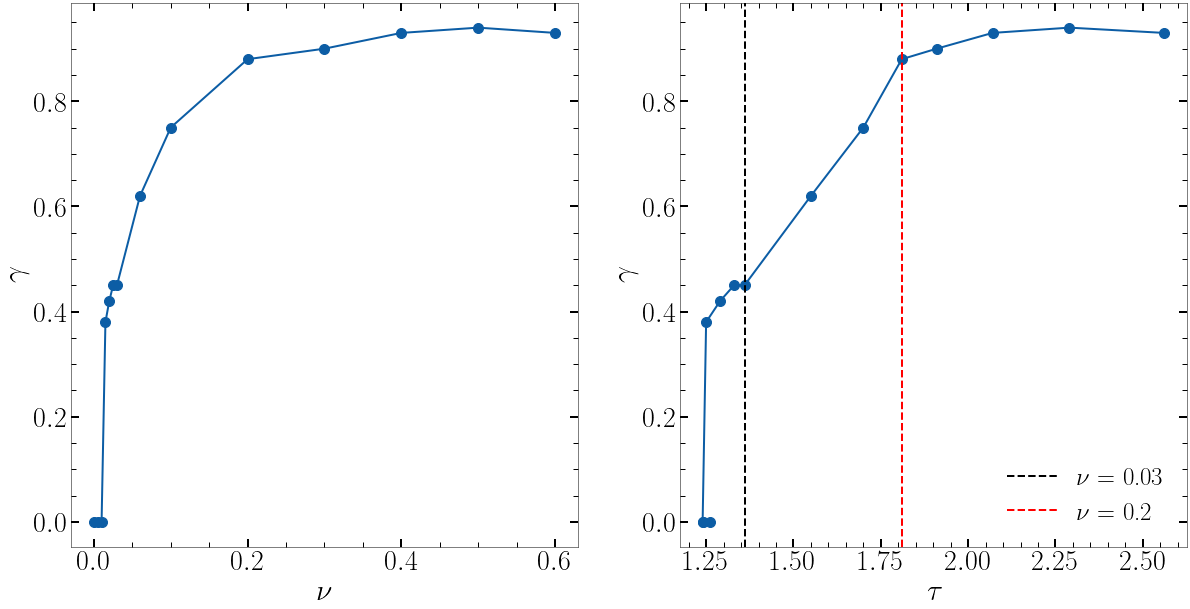

In [132]:
plt.figure(figsize = (20,10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

ax1.plot(Tvar, -Tgamma, lw = 2, marker = 'o', markersize = 10 )
ax2.plot(-Ttau_s, -Tgamma, lw = 2, marker = 'o', markersize = 10 )

ax1.set_xlabel('{}'.format(macros['diss']), fontsize = 30)
ax1.set_ylabel('{}'.format(macros['exp_it']), fontsize = 30)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')

ax2.axvline(-Ttau_s[6], ls = '--', lw =2, c = 'k', label = '{} = {}'.format( macros['diss'], Tvar[6]))
ax2.axvline(-Ttau_s[9], ls = '--', lw =2, c = 'r', label = '{} = {}'.format(macros['diss'], Tvar[9]))
# ax2.axvline(-Ttau_s[12], ls = '--', lw =2, c = 'g', label = '{} = {}'.format(macros['diss'], Tvar[12]))
ax2.set_xlabel('{}'.format(macros['exp_s']), fontsize = 30)
ax2.set_ylabel('{}'.format(macros['exp_it']), fontsize = 30)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
ax2.legend(fontsize = 25)
plt.show()


## $\xi$

In [7]:

L1 = read_parameters("/data1/DATA_Duplat/Brut/PDF/PD1n1")[0]
L2 = read_parameters("/data1/DATA_Duplat/Brut/PDF/PD1n1")[1]

fnb = np.arange(1,15)
# fnb = [8]
folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD1n{nb}' for nb in fnb]
Tnu = [read_parameters(folder)[2] for folder in folderpath]
Tdeltaava = [read_parameters(folder)[-3][1] for folder in folderpath]
Tiniava = [read_parameters(folder)[-3][0] for folder in folderpath]
Tnbava = np.zeros(len(fnb))
Tlimcorr = np.zeros(len(fnb))

for j, folder in enumerate(folderpath):
    with open (f"{folder}/save_B.txt") as f:
        lines = f.readlines()
        
        for line in lines:
            if line.strip() == '' or line.strip().startswith('#'):
                continue
            
            match = re.match(r"([\d\.\+\-eE]+)\s+#Nav", line)
            if match :
                Tnbava[j] = int(match.group(1))
                break
    if j == 12:
        Tnbava[j] = 499900000000
    elif j == 13:
        Tnbava[j] = 1000000000000
    if Tnbava[j] > (read_parameters(folder)[-1][1] * 10):
        Tlimcorr[j] = read_parameters(folder)[-1][1] * 10
    else :
        Tlimcorr[j] = Tnbava[j]
            

Tstartmean = Tlimcorr - (Tlimcorr - Tiniava)*0.1

b = np.zeros(len(folderpath))
b2 = np.zeros(len(folderpath))
b3 = np.zeros(len(folderpath))
b4 = np.zeros(len(folderpath))
b5 = np.zeros(len(folderpath))


for j, (folder, iniava, deltaava, nbava, limcorr, startmean, nu) in enumerate(zip(folderpath, Tiniava, Tdeltaava, Tnbava, Tlimcorr, Tstartmean, Tnu)):
    
    
    clentab , avgtab = corrlength(folder, iniava, deltaava, nbava, L2, switch_plot = 0, numcol = 3)
    b[j] = meancorrfct(folder, deltaava, iniava, L1,L2, limcorr, clentab, startmean, numcol = 3, switch_plot=0)
    
    clentab2 , avgtab2 = corrlength(folder, iniava, deltaava, nbava, L2, switch_plot = 0, numcol = 4)
    b2[j] = meancorrfct(folder, deltaava, iniava, L1,L2, limcorr, clentab2, startmean, numcol = 4, switch_plot=0)
    
    clentab3 , avgtab3 = corrlength(folder, iniava, deltaava, nbava, L2, switch_plot = 0, numcol = 5)
    b3[j] = meancorrfct(folder, deltaava, iniava, L1,L2, limcorr, clentab3, startmean, numcol = 5, switch_plot=0)
    
    clentab4 , avgtab4 = corrlength(folder, iniava, deltaava, nbava, L2, switch_plot = 0, numcol = 6)
    b4[j] = meancorrfct(folder, deltaava, iniava, L1,L2, limcorr, clentab4, startmean, numcol = 6, switch_plot=0)
    
    clentab5 , avgtab5 = corrlength(folder, iniava, deltaava, nbava, L2, switch_plot = 0, numcol = 7)
    b5[j] = meancorrfct(folder, deltaava, iniava, L1,L2, limcorr, clentab5, startmean, numcol = 7, switch_plot=0)
    
    


/home/kduplat/Documents/Data/Pscript/tools.py:125: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x)
/home/kduplat/Documents/Data/Pscript/tools.py:125: RuntimeWarning: overflow encountered in multiply
  return a * np.exp(-b * x)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


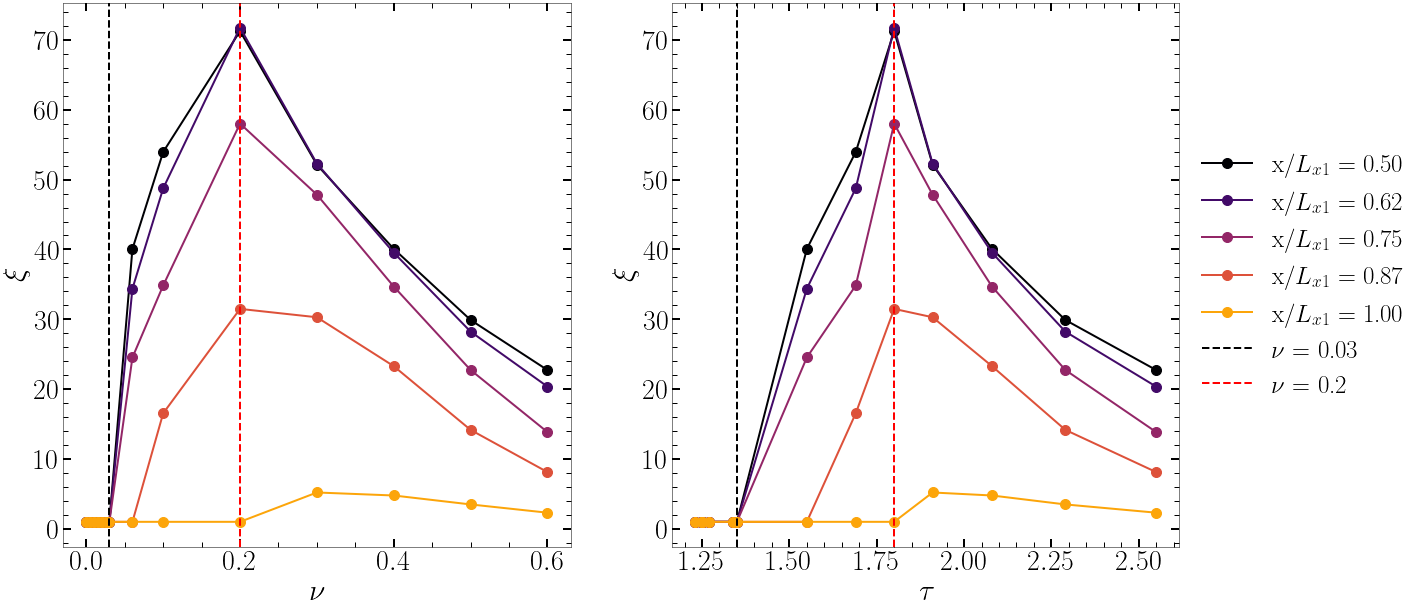

In [9]:
plt.figure(figsize = (20,10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

NCURVES = 5
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]

ax1.plot(Tnu, b, lw = 2, marker = 'o', markersize = 10, label='x/{} = {}'.format(macros['L1'], f'{127/L1:.2f}'), color = colors[0])
ax1.plot(Tnu, b2, lw = 2, marker = 'o', markersize = 10, label='x/{} = {}'.format(macros['L1'], f'{159/L1:.2f}'), color = colors[1] )
ax1.plot(Tnu, b3, lw = 2, marker = 'o', markersize = 10, label='x/{} = {}'.format(macros['L1'], f'{191/L1:.2f}'), color = colors[2] )
ax1.plot(Tnu, b4, lw = 2, marker = 'o', markersize = 10, label='x/{} = {}'.format(macros['L1'], f'{223/L1:.2f}'), color = colors[3] )
ax1.plot(Tnu, b5, lw = 2, marker = 'o', markersize = 10, label='x/{} = {}'.format(macros['L1'], f'{255/L1:.2f}'), color = colors[4] )
ax1.axvline(Tnu[6], ls = '--', lw =2, c = 'k', label = '{} = {}'.format( macros['diss'], Tvar[6]))
ax1.axvline(Tnu[9], ls = '--', lw =2, c = 'r', label = '{} = {}'.format( macros['diss'], Tvar[9]))
# ax1.axvline(Tvar2[12], ls = '--', lw =2, c = 'g', label = '{} = {}'.format( macros['diss'], Tvar[12]))
ax1.set_xlabel('{}'.format(macros['diss']), fontsize = 30)
ax1.set_ylabel('{}'.format(r'$\xi$'), fontsize = 30)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
ax1.legend(loc='center left', bbox_to_anchor=(2.2, 0.5),fontsize = 25)


ax2.plot(-Ttau_s, b, lw = 2, marker = 'o', markersize = 10, color = colors[0] )
ax2.plot(-Ttau_s, b2, lw = 2, marker = 'o', markersize = 10, color = colors[1] )
ax2.plot(-Ttau_s, b3, lw = 2, marker = 'o', markersize = 10, color = colors[2] )
ax2.plot(-Ttau_s, b4, lw = 2, marker = 'o', markersize = 10, color = colors[3] )
ax2.plot(-Ttau_s, b5, lw = 2, marker = 'o', markersize = 10, color = colors[4] )
ax2.axvline(-Ttau_s[6], ls = '--', lw =2, c = 'k')
ax2.axvline(-Ttau_s[9], ls = '--', lw =2, c = 'r')
# ax2.axvline(-Ttau_s[12], ls = '--', lw =2, c = 'g')
ax2.set_xlabel('{}'.format(macros['exp_s']), fontsize = 30)
ax2.set_ylabel('{}'.format(r'$\xi$'), fontsize = 30)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
ax2.legend(fontsize = 25)
plt.show()

## E

### $E_{lost}$

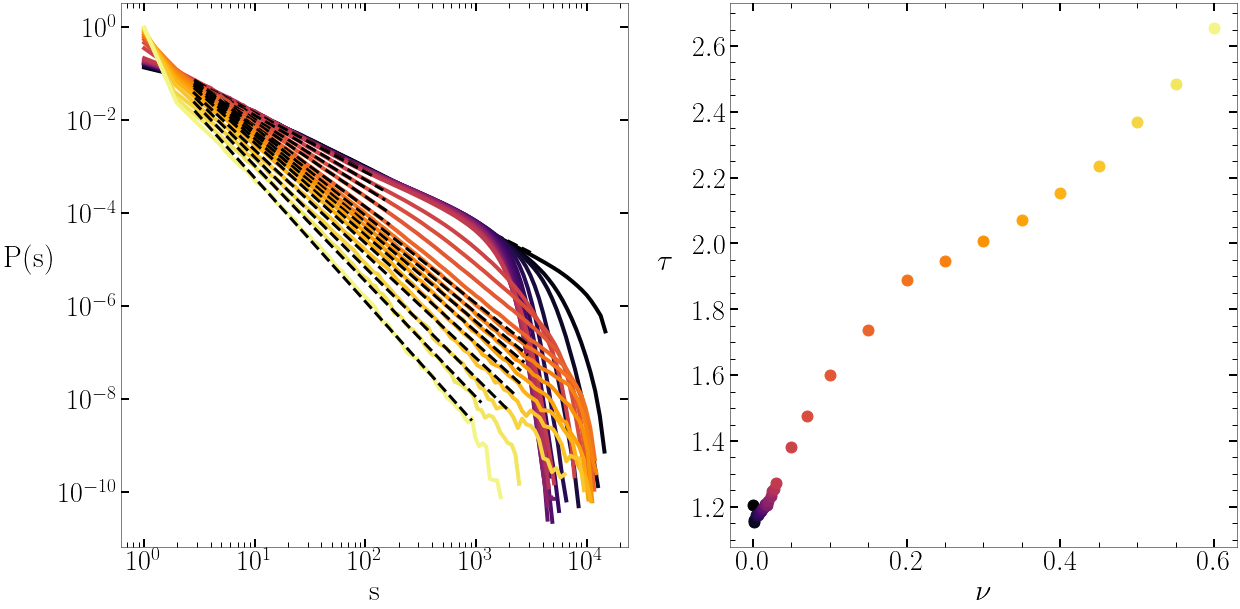

In [13]:
path = "/data1/DATA_Duplat/Brut/E_loss_ava/E_6n"
L1 = read_parameters("/data1/DATA_Duplat/Brut/E_loss_ava/E_6n1")[0]
L2 = read_parameters("/data1/DATA_Duplat/Brut/E_loss_ava/E_6n1")[1]


nbf = np.arange(1,30)
folderpath = [f"{path}{nb}" for nb in nbf]

Tvar = [read_parameters(folder)[2] for folder in folderpath]
Tswitch = np.zeros(len(folderpath))
nbins = 100
Tnmin = [2,1,1,1,1,1,1,1,1,1,
         2,2,2,2,2,2,2,2,2,2,
         2,2,2,2,2,2,2,2,2,2]

Tnmax = [70,37,37,37,37,37,37,37,37,37,
         40,40,40,40,40,40,40,40,40,40,
         70,70,70,70,70,70,70,70,70,70]

var = "nu"
limdata = 1e8

Tndist, Tndatafit, Tnstat = PDF(folderpath, L1, L2, nbins, var, Tvar, Tswitch, Tnmin, Tnmax, switchplot = 1, col = 1, limdata = limdata)

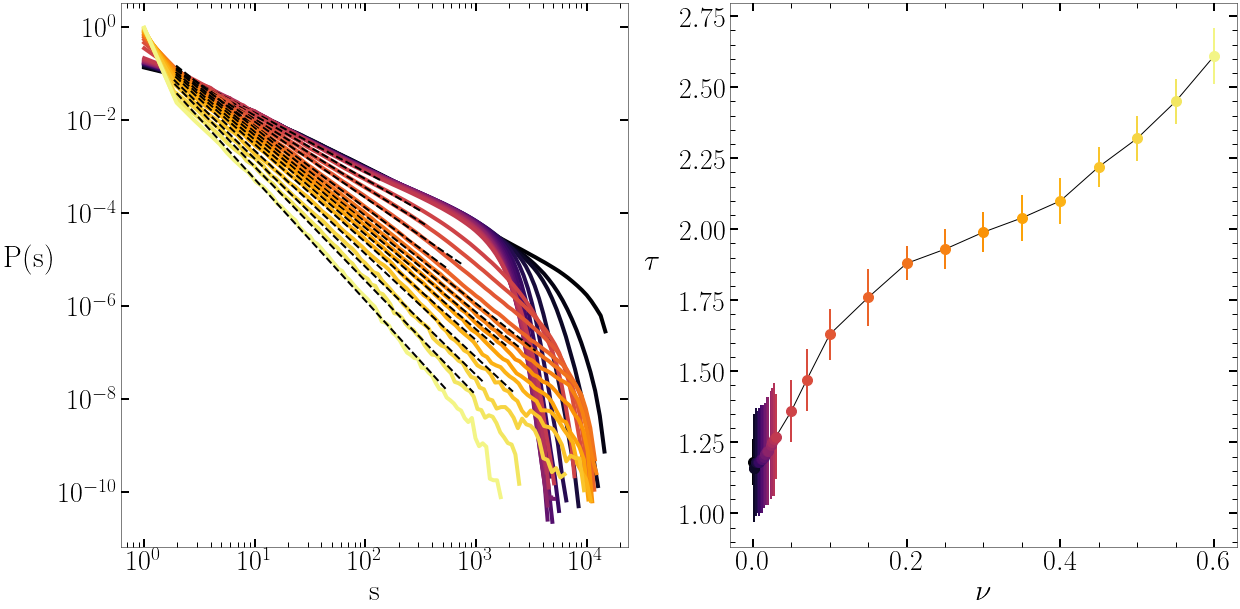

In [14]:
NCURVES = len(folderpath)
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]

plt.figure(figsize=(20,10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

stop = [5e-5,5e-4,1e-3,1e-3,1e-3,1e-3,1e-3,1e-3,1e-3,1e-3,
        1e-3,1e-3,1e-3,1e-3,1e-3,5e-4,1e-4,5e-5,5e-6,5e-6,
        1e-7,1e-7,1e-7,1e-7,1e-7,1e-8,1e-8,1e-8,1e-8,1e-8]
start_x = [4,5,2,2,2,2,1,2,4,4,4,4,4,4,4]
Ttau_s = np.zeros(len(folderpath))
Tperr_s = np.zeros(len(folderpath))

for j, (Tndist_j, Tnstat_j, color_j, nu) in enumerate(zip(Tndist, Tnstat, colors, Tvar)):
    
    mask = Tndist_j[:,1] != 1
    
    if j < 29:
        ax1.plot(Tndist_j[:,0][mask],Tndist_j[:,1][mask], color = color_j,
            linewidth=4, markersize=6, mfc="none", label = f"{nu}\nb = {-Tnstat_j:.2f}") 

        xs_final = 0
        result_final = 0
        perr_final = 1e10
        x_final = 0
        
        try:
            for x in range(1,11):
                result, xs, _ , perr = fit_powerlaw(Tndist_j[:,0][mask], Tndist_j[:,1][mask], n_cutoff = stop[j], start_x = x, f_scale=1.0,
                                        function_to_fit='power')
                if (perr[1] < perr_final):
                    perr_final = perr[1]
                    xs_final = xs
                    result_final = result
                    x_final = x
                    
            # print(x_final)
            ax1.plot(xs_final, powerlaw(xs_final, *result_final.x), 'k--', lw = 2, label='$a={} \pm {}$'.format(np.round(result_final.x[1], 2),
                                                                                    np.round(perr_final, 2)))
        except IndexError:
            print(Tndist_j)
            print(f"Error for element {j}")
            continue

        Ttau_s[j] = np.round(result_final.x[1], 2)
        Tperr_s[j] =  np.round(perr_final, 2)

        # ax2.scatter(Tvar[j], -Tnstat_s[j], color = colors[j], s = 120, zorder= 2)
        ax2.errorbar(nu, - np.round(result_final.x[1], 2), yerr = np.round(perr_final, 2), fmt = 'o', color = color_j, lw =2, markersize = 10)

ax2.plot(Tvar, -Ttau_s, linestyle = '-', c = 'k', zorder=1)

ax1.set_xscale("log")
ax1.set_yscale("log")
# ax1.axvline((L1 * L2)/10, lw = 3)
ax1.set_xlabel('s', fontsize=30)
ax1.set_ylabel('P(s) ', fontsize=30, rotation = 0, labelpad = 30)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')

# ax2.axvline(0.01, c = "k", lw = 2)
ax2.set_xlabel(r'$\nu$', fontsize=30)
ax2.set_ylabel(r'$\tau$', fontsize=30, rotation = 0, labelpad = 30)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
""" plt.legend(title_fontsize = 23, ncol = 2, loc='center left', bbox_to_anchor=(1, 0.5),fontsize = 25) """
plt.show()

In [17]:
def chunked_file_reader(filepath, chunksize=1e7, usecols=None):
   for chunk in pd.read_csv(filepath, compression='gzip', delim_whitespace=True, header=None, chunksize=chunksize, usecols=usecols):
      yield chunk

def process_folderE(folder, v):

   E_loss_mean, E_moved, E_max_sweep, E_max_site, E_lost_border, nbline, S_max, S_mean, Top_mean  = 0,0,0,0,0,0,0,0,0
   top_100 = []
   
   for chunk in chunked_file_reader(f'{folder}/Avalanche_outputB.gz', chunksize=1e7):
         
      diff = abs(chunk.iloc()[:, 6] - chunk.iloc()[:, 7])
      E_loss_mean += np.sum(diff)
      E_moved += np.sum(chunk.iloc()[:, 8])
      E_max_sweep += np.sum(chunk.iloc()[:, 9])
      E_max_site += np.sum(chunk.iloc()[:, 10])
      E_lost_border += np.sum(chunk.iloc()[:, 11] / (1 - v))  # (It was saved after the influence of the dissipation)
      nbline += len(chunk)
      
      S_mean += np.sum(chunk.iloc()[:, 1])
      S_max = max(S_max, np.max(chunk.iloc[:, 1]))
      
      Top_mean += np.sum(chunk.iloc()[:, 4]) 
            
      top_100.extend(chunk.iloc[:, 1])
      if len(top_100) > 100:
            top_100 = list(np.partition(np.array(top_100), -100)[-100:])
            
      if nbline == 1e7:
         break
   

   
   E_loss_mean = E_loss_mean / nbline
   E_moved = E_moved / nbline
   E_max_sweep = E_max_sweep / nbline
   E_max_site = E_max_site / nbline
   E_lost_border = E_lost_border / nbline
   S_mean = S_mean/nbline
   Top_mean = Top_mean/nbline
   
   if len(top_100) > 100:
      top_100 = list(np.partition(np.array(top_100, -100)[-100:]))
   S_max_mean = np.mean(top_100)
   
   return E_loss_mean, E_moved, E_max_sweep, E_max_site, E_lost_border, S_mean, S_max, S_max_mean, Top_mean



In [18]:

fnb = np.arange(1,30)
folderpath = [f'/data1/DATA_Duplat/Brut/E_loss_ava/E_6n{nb}' for nb in fnb]

Tnu = [0, 0.001, 0.002, 0.004, 0.006, 0.008, 0.01, 0.012, 0.014, 0.016,
       0.018, 0.02, 0.023, 0.025, 0.027, 0.03, 0.05, 0.07, 0.1, 0.15,
       0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]


NCURVES = len(folderpath) + 3 
cmap = plt.cm.get_cmap('viridis')
colors = [cmap(1 - i / NCURVES) for i in range(NCURVES)]

E_loss_mean = np.zeros(len(folderpath))
E_moved = np.zeros(len(folderpath))
E_max_sweep = np.zeros(len(folderpath))
E_max_site = np.zeros(len(folderpath))
E_lost_border = np.zeros(len(folderpath))

S_mean = np.zeros(len(folderpath))
S_max = np.zeros(len(folderpath))
S_max_mean = np.zeros(len(folderpath))

Top_mean = np.zeros(len(folderpath))

results = Parallel(n_jobs=-1)(delayed(process_folderE)(folder, v) for folder, v in zip(folderpath, Tnu))

for i, result in enumerate(results):
       E_loss_mean[i], E_moved[i], E_max_sweep[i], E_max_site[i], E_lost_border[i], S_mean[i], S_max[i], S_max_mean[i], Top_mean[i] = result



In [15]:
Tnu = [0, 0.001, 0.002, 0.004, 0.006, 0.008, 0.01, 0.012, 0.014, 0.016,
       0.018, 0.02, 0.023, 0.025, 0.027, 0.03, 0.05, 0.07, 0.1, 0.15,
       0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
ones = np.ones(len(Tnu))
E_max_sweep_diss = E_max_sweep * (ones - Tnu)
E_moved_diss = E_moved * (ones - Tnu)
E_max_site_diss = E_max_site * (ones - Tnu)
E_lost_border_diss = E_lost_border * (ones - Tnu)
E_lost_diss = (E_moved - E_lost_border) * Tnu


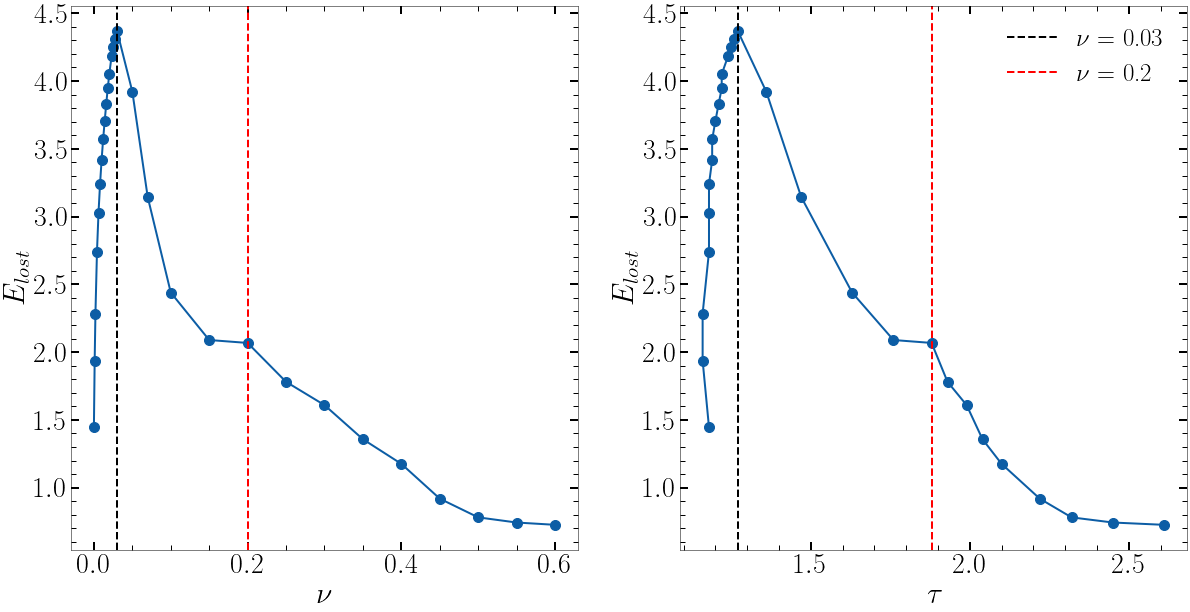

In [16]:
Tnu = [0, 0.001, 0.002, 0.004, 0.006, 0.008, 0.01, 0.012, 0.014, 0.016,
       0.018, 0.02, 0.023, 0.025, 0.027, 0.03, 0.05, 0.07, 0.1, 0.15,
       0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

plt.figure(figsize = (20,10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

ax1.plot(Tnu, E_loss_mean, lw = 2, marker = 'o', markersize = 10)
ax2.plot(-Ttau_s, E_loss_mean, lw = 2, marker = 'o', markersize = 10)

ax1.set_xlabel('{}'.format(macros['diss']), fontsize = 30)
ax1.set_ylabel('{}'.format(r'$E_{lost}$'), fontsize = 30)
ax1.axvline(Tnu[15], ls = '--', lw =2, c = 'k', label = '{} = {}'.format( macros['diss'], Tnu[15]))
ax1.axvline(Tnu[20], ls = '--', lw =2, c = 'r', label = '{} = {}'.format(macros['diss'], Tnu[20]))
# ax1.axvline(Tnu[26], ls = '--', lw =2, c = 'g', label = '{} = {}'.format(macros['diss'], Tvar[26]))
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')


ax2.set_xlabel('{}'.format(macros['exp_s']), fontsize = 30)
ax2.set_ylabel('{}'.format(r'$E_{lost}$'), fontsize = 30)
ax2.axvline(-Ttau_s[15], ls = '--', lw =2, c = 'k', label = '{} = {}'.format( macros['diss'], Tnu[15]))
ax2.axvline(-Ttau_s[20], ls = '--', lw =2, c = 'r', label = '{} = {}'.format(macros['diss'], Tnu[20]))
# ax2.axvline(-Ttau_s[26], ls = '--', lw =2, c = 'g', label = '{} = {}'.format(macros['diss'], Tvar[26]))
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
ax2.legend(fontsize = 25)
plt.show()

### $E_{lost\_by\_dissipation}$

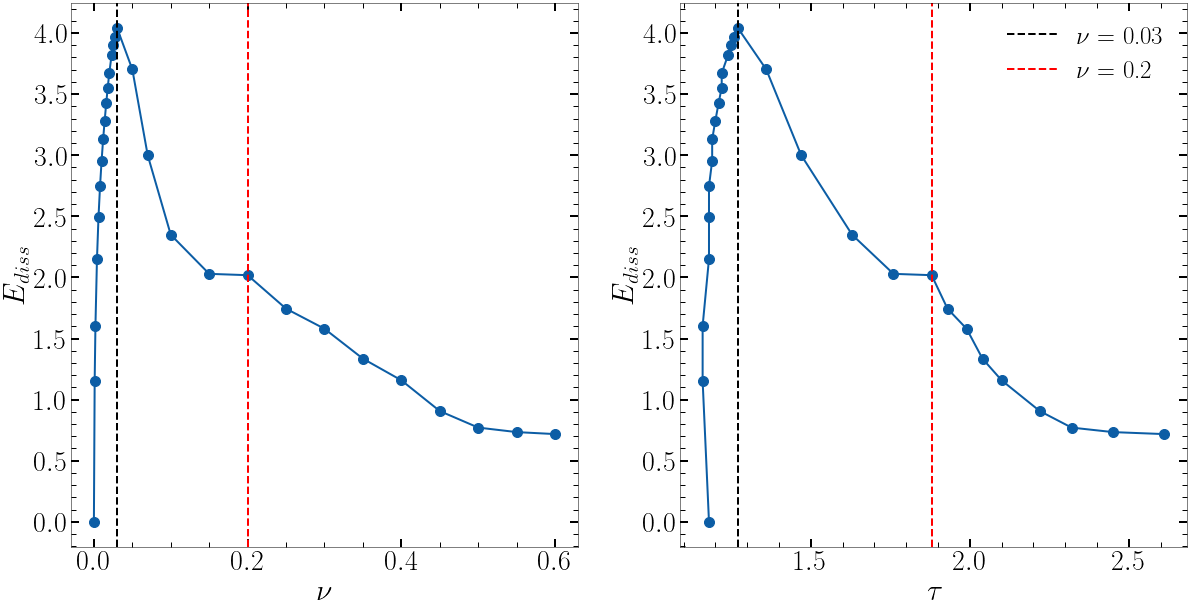

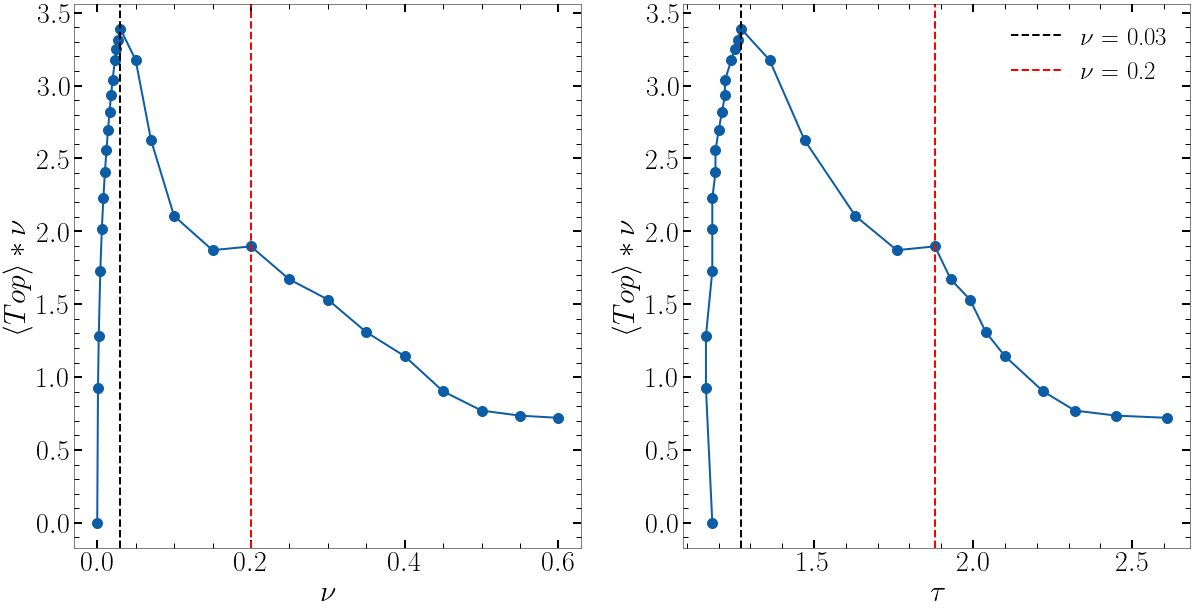

In [22]:



plt.figure(figsize = (20,10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

ax1.plot(Tnu, E_lost_diss, lw = 2, marker = 'o', markersize = 10)
ax2.plot(-Ttau_s, E_lost_diss, lw = 2, marker = 'o', markersize = 10 )

ax1.set_xlabel('{}'.format(macros['diss']), fontsize = 30)
ax1.set_ylabel('{}'.format(r'$E_{diss}$'), fontsize = 30)
ax1.axvline(Tnu[15], ls = '--', lw =2, c = 'k', label = '{} = {}'.format( macros['diss'], Tnu[15]))
ax1.axvline(Tnu[20], ls = '--', lw =2, c = 'r', label = '{} = {}'.format(macros['diss'], Tnu[20]))
# ax1.axvline(Tnu[26], ls = '--', lw =2, c = 'g', label = '{} = {}'.format(macros['diss'], Tvar[26]))
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')


ax2.set_xlabel('{}'.format(macros['exp_s']), fontsize = 30)
ax2.set_ylabel('{}'.format(r'$E_{diss}$'), fontsize = 30)
ax2.axvline(-Ttau_s[15], ls = '--', lw =2, c = 'k', label = '{} = {}'.format( macros['diss'], Tnu[15]))
ax2.axvline(-Ttau_s[20], ls = '--', lw =2, c = 'r', label = '{} = {}'.format(macros['diss'], Tnu[20]))
# ax2.axvline(-Ttau_s[26], ls = '--', lw =2, c = 'g', label = '{} = {}'.format(macros['diss'], Tvar[26]))
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
ax2.legend(fontsize = 25)
plt.show()

plt.figure(figsize = (20,10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

ax1.plot(Tnu, Top_mean * Tnu, lw = 2, marker = 'o', markersize = 10)
ax2.plot(-Ttau_s, Top_mean * Tnu, lw = 2, marker = 'o', markersize = 10)

ax1.set_xlabel('{}'.format(macros['diss']), fontsize = 30)
ax1.set_ylabel('{}'.format(r'$\langle Top \rangle * \nu$'), fontsize = 30)
ax1.axvline(Tnu[15], ls = '--', lw =2, c = 'k', label = '{} = {}'.format( macros['diss'], Tnu[15]))
ax1.axvline(Tnu[20], ls = '--', lw =2, c = 'r', label = '{} = {}'.format(macros['diss'], Tnu[20]))
# ax1.axvline(Tnu[26], ls = '--', lw =2, c = 'g', label = '{} = {}'.format(macros['diss'], Tvar[26]))
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')


ax2.set_xlabel('{}'.format(macros['exp_s']), fontsize = 30)
ax2.set_ylabel('{}'.format(r'$\langle Top \rangle * \nu$'), fontsize = 30)
ax2.axvline(-Ttau_s[15], ls = '--', lw =2, c = 'k', label = '{} = {}'.format( macros['diss'], Tnu[15]))
ax2.axvline(-Ttau_s[20], ls = '--', lw =2, c = 'r', label = '{} = {}'.format(macros['diss'], Tnu[20]))
# ax2.axvline(-Ttau_s[26], ls = '--', lw =2, c = 'g', label = '{} = {}'.format(macros['diss'], Tvar[26]))
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
ax2.legend(fontsize = 25)
plt.show()


### $E_{lost\_by\_borders}$

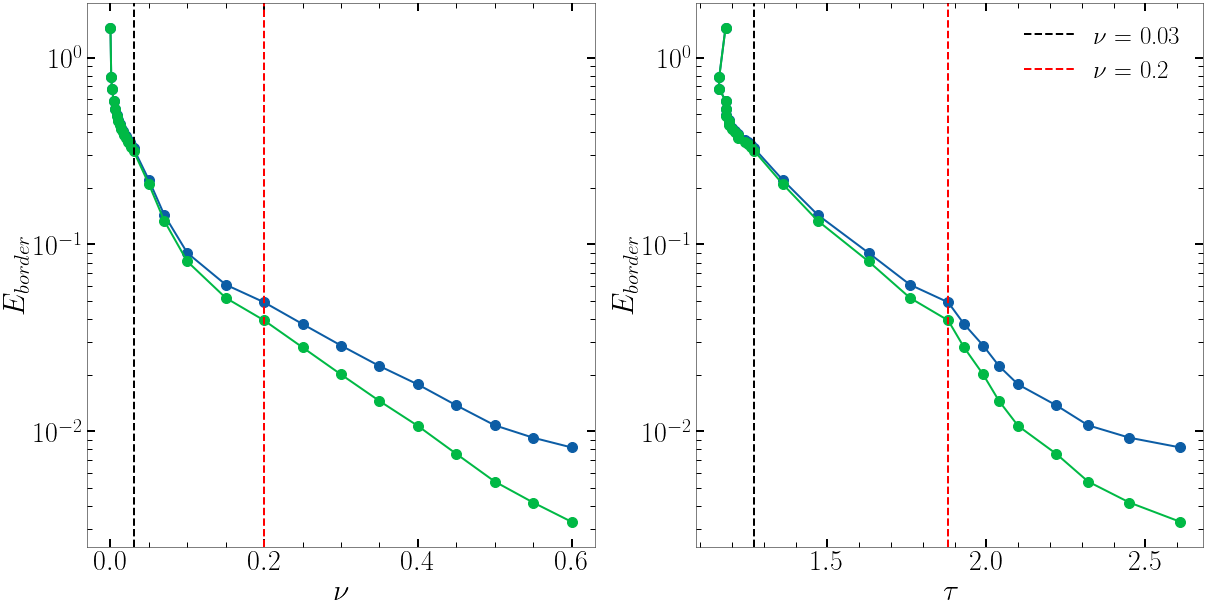

In [143]:

# plt.figure(figsize = (10,10))
# plt.plot(-Ttau_s, E_lost_border, lw = 2, marker = 'o', markersize = 10, label = "Before dissipation" )
# plt.plot(-Ttau_s, E_lost_border_diss, lw = 2, marker = 'o', markersize = 10,  label = "After dissipation")
# plt.axvline(-Ttau_s[15], ls = '--', lw =2, c = 'k', label = '{} = {}'.format( macros['diss'], Tnu[15]))
# plt.axvline(-Ttau_s[20], ls = '--', lw =2, c = 'r', label = '{} = {}'.format(macros['diss'], Tnu[20]))
# plt.axvline(-Ttau_s[27], ls = '--', lw =2, c = 'g', label = '{} = {}'.format(macros['diss'], Tvar[27]))
# plt.xlabel('{}'.format(macros['exp_s']), fontsize = 30)
# plt.ylabel('{}'.format(r'$E_{border}$'), fontsize = 30)
# plt.yscale('log')
# plt.tick_params(labelsize = 28,length = 8, width = 2)
# plt.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
# plt.legend(fontsize = 25)
# plt.show()

plt.figure(figsize = (20,10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

ax1.plot(Tnu, E_lost_border, lw = 2, marker = 'o', markersize = 10)
ax1.plot(Tnu, E_lost_border_diss, lw = 2, marker = 'o', markersize = 10)
ax2.plot(-Ttau_s, E_lost_border, lw = 2, marker = 'o', markersize = 10 )
ax2.plot(-Ttau_s, E_lost_border_diss, lw = 2, marker = 'o', markersize = 10 )

ax1.set_xlabel('{}'.format(macros['diss']), fontsize = 30)
ax1.set_ylabel('{}'.format(r'$E_{border}$'), fontsize = 30)
ax1.axvline(Tnu[15], ls = '--', lw =2, c = 'k', label = '{} = {}'.format( macros['diss'], Tnu[15]))
ax1.axvline(Tnu[20], ls = '--', lw =2, c = 'r', label = '{} = {}'.format(macros['diss'], Tnu[20]))
# ax1.axvline(Tnu[26], ls = '--', lw =2, c = 'g', label = '{} = {}'.format(macros['diss'], Tvar[26]))
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
ax1.set_yscale('log')

ax2.set_xlabel('{}'.format(macros['exp_s']), fontsize = 30)
ax2.set_ylabel('{}'.format(r'$E_{border}$'), fontsize = 30)
ax2.axvline(-Ttau_s[15], ls = '--', lw =2, c = 'k', label = '{} = {}'.format( macros['diss'], Tnu[15]))
ax2.axvline(-Ttau_s[20], ls = '--', lw =2, c = 'r', label = '{} = {}'.format(macros['diss'], Tnu[20]))
# ax2.axvline(-Ttau_s[26], ls = '--', lw =2, c = 'g', label = '{} = {}'.format(macros['diss'], Tvar[26]))
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
ax2.set_yscale('log')
ax2.legend(fontsize = 25)
plt.show()
